In [1]:
import pandas as pd

# Data loading FD001 training set

In [2]:
filepath="../data/train_FD001.txt"
train_df_full=pd.read_csv(filepath,
               sep=r"\s+",
               header=None)

In [3]:
train_df_full.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


# Data Understanding

Went through the readme and other online sources alongside the code below to prepare the data for better initial insights.

In [4]:
train_df_full.shape

(20631, 26)

In [5]:
train_df_full.columns=(["unit_num","cycle"]+
            [f"operational_set_{i}" for i in range(1,4)]+
            [f"sensor_{i}" for i in range(1,22)])
train_df_full.head()

,unit_num,cycle,operational_set_1,operational_set_2,operational_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Observations:

+ one row = one engine at one operating cycle
+ unit_num identifies the engine 
+ cycle refer to the engine's operating cycle
+ multile rows belong to a single engine
+ the observed number of cycles for each engine varies
+ 3 operational settings available
+ 21 sensor measurements

In [6]:
train_df_full.isnull().sum()

unit_num             0
cycle                0
operational_set_1    0
operational_set_2    0
operational_set_3    0
sensor_1             0
sensor_2             0
sensor_3             0
sensor_4             0
sensor_5             0
sensor_6             0
sensor_7             0
sensor_8             0
sensor_9             0
sensor_10            0
sensor_11            0
sensor_12            0
sensor_13            0
sensor_14            0
sensor_15            0
sensor_16            0
sensor_17            0
sensor_18            0
sensor_19            0
sensor_20            0
sensor_21            0
dtype: int64

In [7]:
train_df_full.duplicated().sum()

np.int64(0)

In [8]:
train_df_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   unit_num           20631 non-null  int64  
 1   cycle              20631 non-null  int64  
 2   operational_set_1  20631 non-null  float64
 3   operational_set_2  20631 non-null  float64
 4   operational_set_3  20631 non-null  float64
 5   sensor_1           20631 non-null  float64
 6   sensor_2           20631 non-null  float64
 7   sensor_3           20631 non-null  float64
 8   sensor_4           20631 non-null  float64
 9   sensor_5           20631 non-null  float64
 10  sensor_6           20631 non-null  float64
 11  sensor_7           20631 non-null  float64
 12  sensor_8           20631 non-null  float64
 13  sensor_9           20631 non-null  float64
 14  sensor_10          20631 non-null  float64
 15  sensor_11          20631 non-null  float64
 16  sensor_12          20631 non-null

In [9]:
train_df_full.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_num,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
operational_set_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
operational_set_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
operational_set_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


## Observations:

+ certain features lack variance.

In [10]:
train_df_full.nunique().sort_values()


sensor_1                1
operational_set_3       1
sensor_10               1
sensor_5                1
sensor_19               1
sensor_16               1
sensor_18               1
sensor_6                2
sensor_17              13
operational_set_2      13
sensor_8               53
sensor_13              56
unit_num              100
sensor_20             120
operational_set_1     158
sensor_11             159
sensor_2              310
cycle                 362
sensor_12             427
sensor_7              513
sensor_15            1918
sensor_3             3012
sensor_4             4051
sensor_21            4745
sensor_14            6078
sensor_9             6403
dtype: int64

## Observations:

+ Seven variables (sensor_1, operational_set_3, sensor_10, sensor_5, sensor_19, sensor_16, sensor_18) have no variations across the dataset and carry no predictive power because they cannot differentiate between a healthy engine and a failing one. So, these are are candidates for removal during preprocessing.
+ Sensor 6 & 17, & operational setting 2 are near-constant thus they must be examined as well.

In [11]:
engine_lifetime=train_df_full.groupby("unit_num")["cycle"].max()
engine_lifetime.describe().T

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

## Observations:
Engine lifetime varies from 128 cycles to 362 cycles, across the 100 engines. A difference of nearly 235 cycles between the shortest and longest-running units.

In [12]:
import matplotlib.pyplot as plt

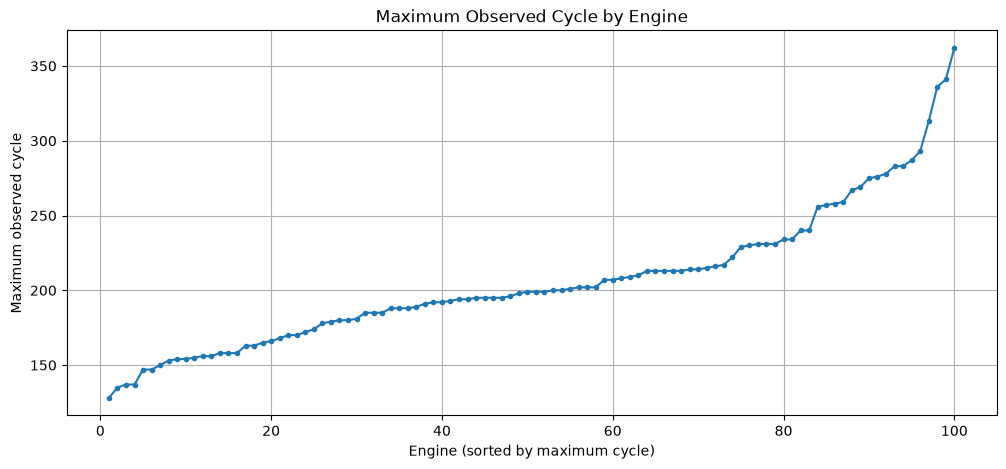

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    range(1,len(engine_lifetime) +1),
    sorted(engine_lifetime.values),
    marker="o",
    markersize=3
)

plt.xlabel("Engine (sorted by maximum cycle)")
plt.ylabel("Maximum observed cycle")
plt.title("Maximum Observed Cycle by Engine")
plt.grid(True)
plt.show()

## Observations:
+ Engine units 1 to ~20 show early failure (120-~170 cycles)
+ Engine Units between 20 and 80 construct the median range where max cycles are relatively closer in count and show a gradual upward trend to denote growing lifetimes.
+ Engine units from 80 till 96 show a greater growth, though not that substantial.
+ A spike is noticed on the right tail, i.e., engine units 96 to 100 show drastic increase in cycles till failure.


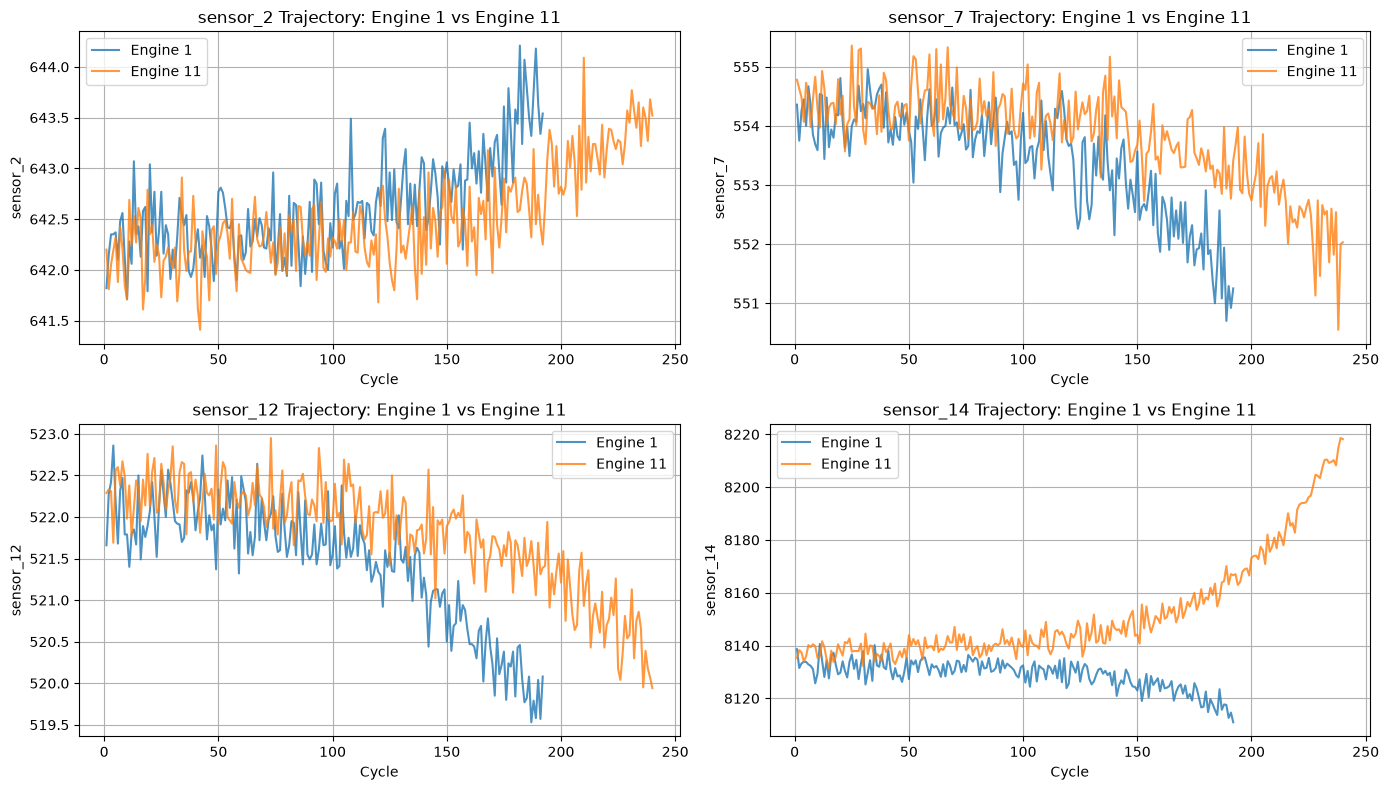

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sensors_to_check = ["sensor_2", "sensor_7", "sensor_12", "sensor_14"]

eng1 = train_df_full[train_df_full["unit_num"] == 1]
eng11 = train_df_full[train_df_full["unit_num"] == 11]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, sensor in enumerate(sensors_to_check):
    axes[i].plot(eng1["cycle"], eng1[sensor], label="Engine 1", alpha=0.8)
    axes[i].plot(eng11["cycle"], eng11[sensor], label="Engine 11", alpha=0.8)
    axes[i].set_xlabel("Cycle")
    axes[i].set_ylabel(sensor)
    axes[i].set_title(f"{sensor} Trajectory: Engine 1 vs Engine 11")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

## Observations:
+ High Noise vs. Smooth Signals: Sensors 2, 7, and 12 exhibit significant cycle-to-cycle operational noise, whereas sensor 14 displays a very smooth, low-noise signal curve.
+ Consistent Monotonic Trends (Sensors 2, 7, 12): sensor_2 (LPC Outlet Temp) shows a clear upward drift for both engines as heat builds up due to internal component degradation & sensor_7 (HPT Outlet Pressure) & sensor_12 (Pressure Ratio) show a downward drift for both engines, reflecting lost compression efficiency over time.
+ Accelerated Knee Effect near Failure: Across all sensors, degradation speeds up sharply in the final ~30–50 cycles before total engine failure.
+ sensor_14 (Core Speed): Shows distinct baseline differences between units, with Engine 11 exhibiting a strong upward exponential trend near end-of-life compared to Engine 1's mild decline.

In [15]:
cycle_diff=train_df_full.groupby("unit_num")["cycle"].diff().dropna()
cycle_diff[cycle_diff != 1].count()

np.int64(0)

# Target Engineering (creating RUL) & Analysis

In [16]:
train_df_full["maxc"]=train_df_full.groupby("unit_num")["cycle"].transform("max")
train_df_full["rul_train_full"]=train_df_full["maxc"]-train_df_full["cycle"]
train_df_full.drop(columns=["maxc"],inplace=True) 

In [17]:
train_df_full.head()


,unit_num,cycle,operational_set_1,operational_set_2,operational_set_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,rul_train_full
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [18]:
train_df_full.rul_train_full.describe()

count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: rul_train_full, dtype: float64

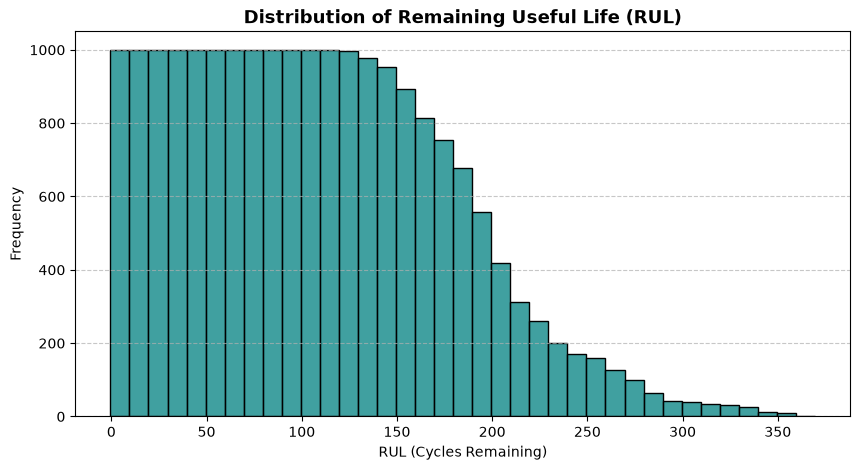

In [19]:
import numpy as np

bin_edges = np.arange(-0.5, train_df_full["rul_train_full"].max() + 10, 10)

plt.figure(figsize=(10, 5))
sns.histplot(
    data=train_df_full,
    x="rul_train_full",
    bins=bin_edges,
    color="teal"
)
plt.title("Distribution of Remaining Useful Life (RUL)", fontsize=13, fontweight="bold")
plt.xlabel("RUL (Cycles Remaining)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


## Observations:
+ RUL for all engines takes at least 128 cycles since the shortest lifecycle of engines is 128 cycles. This has been confirmed from this visualization since RUL from 0 to ~130 is a flat plateau.
+ It is also very evident that very few engines have lifecycles close to 370 ( bins hold 10 cycles each so maximum lifecycle of 362 cycles falls in the 360-370 bin ).
+ The initial plateau from 0-~130 is thus, followed by a gradual decrease and a large amount of short living engines fail before reaching 230 cycles and even less move towards 360-370 cycles, creating a right tapered tail.

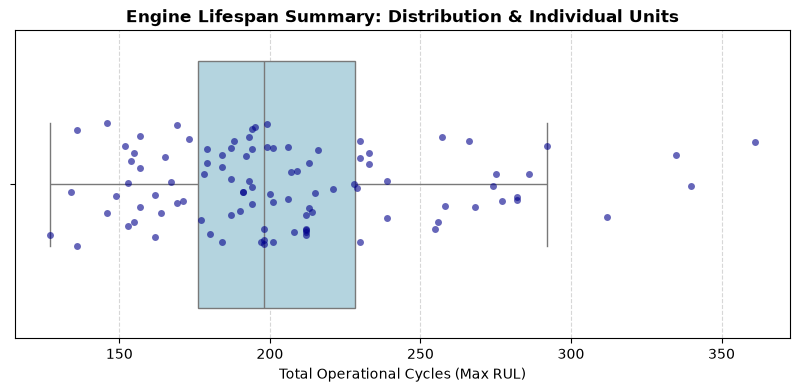

In [20]:
engine_lifespans = train_df_full.groupby("unit_num")["rul_train_full"].max().reset_index()
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=engine_lifespans,
    x="rul_train_full",
    color="lightblue",
    fliersize=0  
)

sns.stripplot(
    data=engine_lifespans,
    x="rul_train_full",
    color="darkblue",
    alpha=0.6,
    jitter=0.2
)

plt.title("Engine Lifespan Summary: Distribution & Individual Units", fontsize=12, fontweight="bold")
plt.xlabel("Total Operational Cycles (Max RUL)")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()


## Observations:
+ The boxplot shows that the median lifespan is at ~200 cycles and most engines have ~170 to ~215 maximum cycles[middle 50%]
+ There are few fliers,i.e., only a few engines go above the 300 max RUL mark, demonstrating their high durability.
+ Since individual engine lifespans vary by nearly 3x (128 vs 362 cycles), predictions based solely on raw cycle count will be inaccurate. Features must capture degradation trends (rate of sensor change) rather than elapsed operating time alone

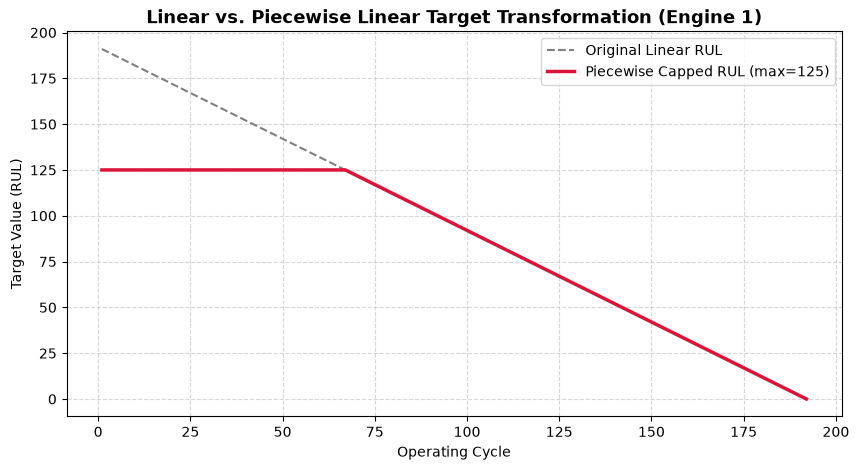

In [21]:
CAP_THRESHOLD = 125
train_df_full["rul_piecewise"] = train_df_full["rul_train_full"].clip(upper=CAP_THRESHOLD)
plt.figure(figsize=(10, 5))

sample_engine = train_df_full[train_df_full["unit_num"] == 1]

plt.plot(sample_engine["cycle"], sample_engine["rul_train_full"], label="Original Linear RUL", linestyle="--", color="gray")
plt.plot(sample_engine["cycle"], sample_engine["rul_piecewise"], label=f"Piecewise Capped RUL (max={CAP_THRESHOLD})", color="crimson", linewidth=2.5)
plt.title("Linear vs. Piecewise Linear Target Transformation (Engine 1)", fontsize=13, fontweight="bold")
plt.xlabel("Operating Cycle")
plt.ylabel("Target Value (RUL)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## Observations: 
+ Original Linear RUL: The true RUL decreases at a constant rate starting from the engine's initial cycle down to 0 at failure.
+ Piecewise Capped RUL: The modified target stays flat at 125 during the engine's early life (cycles 1 to ~62) and only begins its linear decline once the remaining useful life drops below 125.
+ Transition Point: The plot clearly demonstrates the inflection point at cycle ~62, where the target transitions from a constant healthy baseline (125) to an active countdown towards failure.